## Submission checklist

`Please checkout this repo link - `[https://github.com/ouut/AIG240_Robotics/blob/main/Lab2_Submission_ChaoChen.ipynb](https://github.com/ouut/AIG240_Robotics/blob/main/Lab2_Submission_ChaoChen.ipynb)

Include:
1. Screenshot: turtlesim showing your chosen background color.
   - 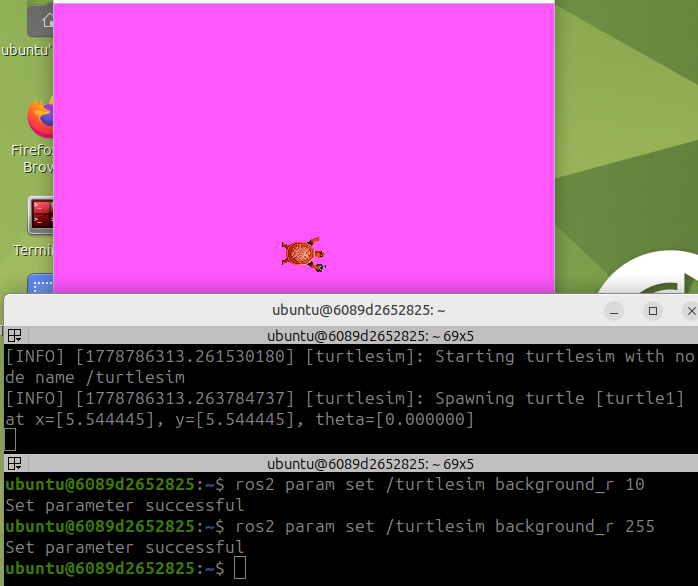
3. Screenshot: `rqt_graph` showing **two** command publishers and **two** turtle cmd_vel topics.
   - 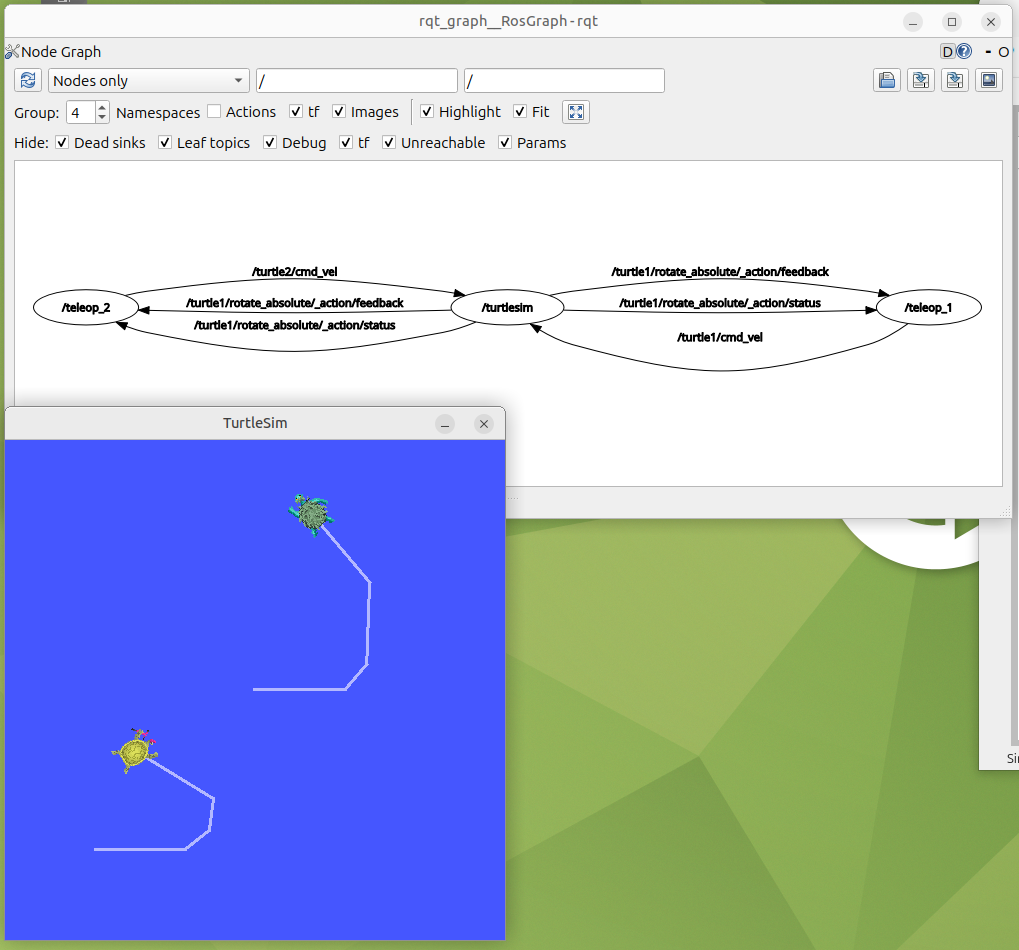
5. Terminal output:
   - `ros2 node list`
       - 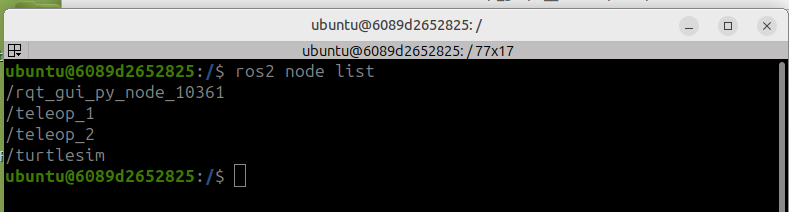
   - `ros2 topic list -v`
       - 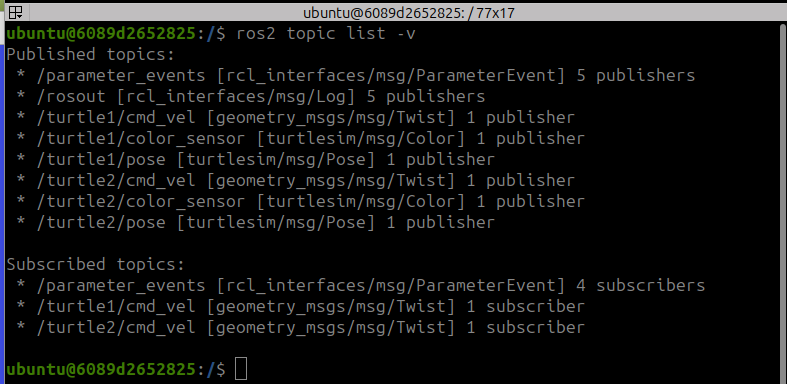
   - `ros2 service list`
       - 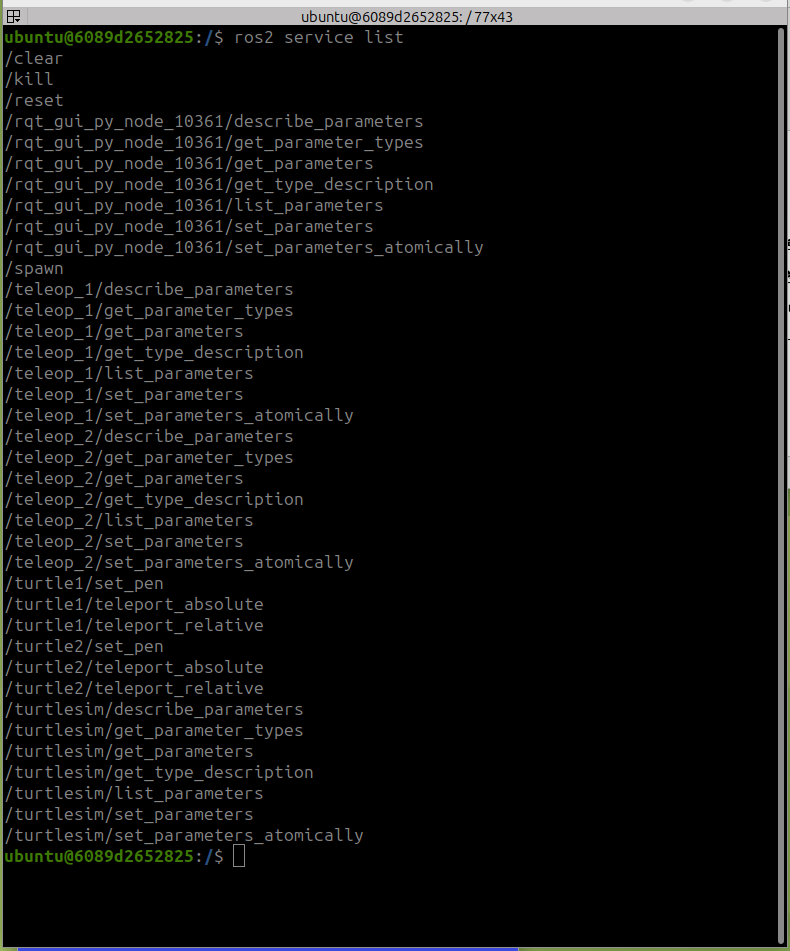
   - `ros2 param list`
       - 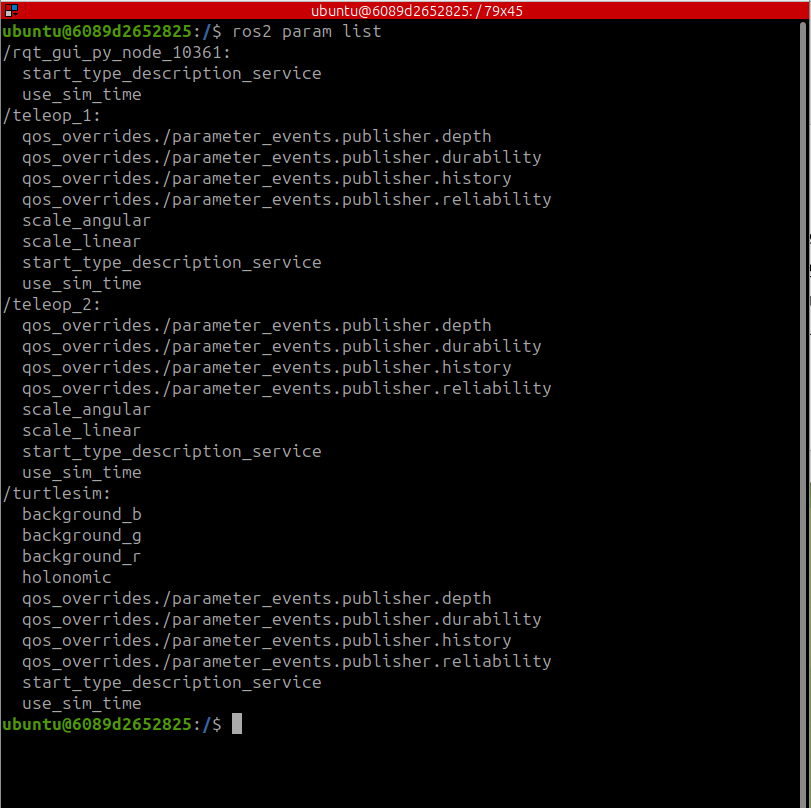
6. Short answers (2–4 sentences each):
   - What is the difference between **topics** and **services**?
        * topic relates to a design pattern in software - publish/subscribe
    publish node send a message to a topic and all subscribe nodes will get the message.
        * this design decouple the system,allowing nodes to be added easily without affecting others.
        * A service relates to a remote procedure call (RPC): one node exposes a function (the service server), and another node (the client) can call this API directly to get a synchronous return.
   - Why does changing background parameters require calling `/clear` to visually update?
        * In ros2, I run the following commands and the background became black immediately
          ```bash
               ros2 param set /turtlesim background_r 0
               ros2 param set /turtlesim background_g 0
               ros2 param set /turtlesim background_b 0
           ```
        * 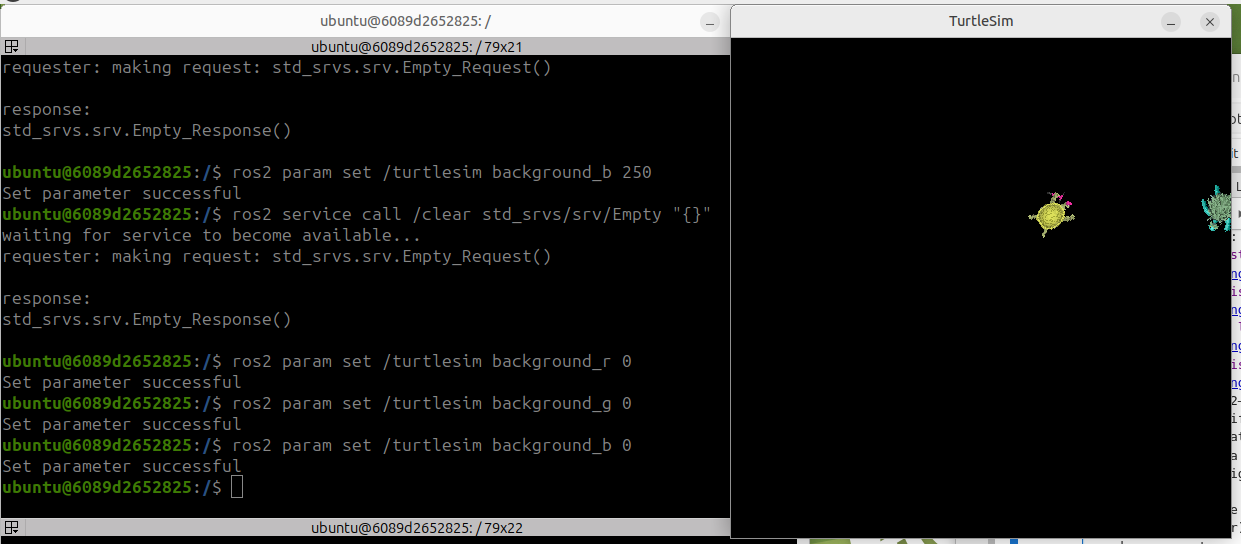
        * `ros2 service call /clear std_srvs/srv/Empty "{}"`
        * clear command only removed the turtle trace and did not make the background visually update in ros2
   - What is one debugging step you would do first if the turtle does not move?
        * I will check if the /turtle1/cmd_vel has a publisher, and run the fllowing commnad:`ros2 topic info /turtle1/cmd_vel`
        * 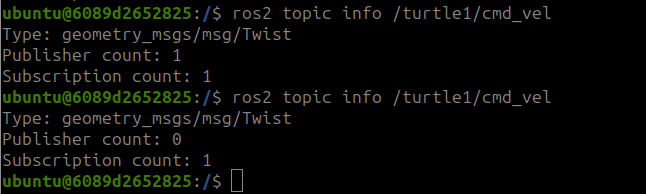



---
## Appendix — Ubuntu 24.04 Track (ROS 2 Jazzy equivalents)

If you are on **Ubuntu 24.04**, use **ROS 2 Jazzy** and the equivalent commands below.

### Bring up turtlesim
```bash
ros2 run turtlesim turtlesim_node
ros2 run turtlesim turtle_teleop_key
```

### Nodes / Topics
```bash
ros2 node list
ros2 node info /turtlesim
ros2 topic list
ros2 topic info /turtle1/cmd_vel
ros2 topic echo --once /turtle1/pose
```

### Publish Twist (ROS 2 uses YAML)
```bash
ros2 topic pub --once /turtle1/cmd_vel geometry_msgs/msg/Twist "{linear: {x: 2.0, y: 0.0, z: 0.0}, angular: {z: 1.8}}"
ros2 topic pub /turtle1/cmd_vel geometry_msgs/msg/Twist "{linear: {x: 2.0}, angular: {z: -1.8}}" -r 1
```

### Services (spawn, set_pen, clear)
```bash
ros2 service list
ros2 service type /spawn
ros2 interface show turtlesim/srv/Spawn

ros2 service call /spawn turtlesim/srv/Spawn "{x: 2.0, y: 2.0, theta: 0.2, name: 'turtle2'}"
ros2 service call /clear std_srvs/srv/Empty "{}"
ros2 service call /turtle1/set_pen turtlesim/srv/SetPen "{r: 0, g: 255, b: 255, width: 5, off: 0}"
```

### Parameters (ROS 2 uses `ros2 param`)
```bash
ros2 param list
ros2 param get /turtlesim background_r
ros2 param set /turtlesim background_r 150
ros2 service call /clear std_srvs/srv/Empty "{}"
```
